In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("car_price.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  object 
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  object 
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  object 
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  object 
dtypes: float64(6), object(4)
memory usage: 5.5+ MB


# EDA

In [6]:
TARGET = 'price'
CAT_FEATURES = ['transmission', 'fuelType', 'Make']
NUM_FEATURES = ['mileage', 'tax', 'mpg', 'engineSize']
MIXED_FEATURES = ['model']
DATE_FEATURE = ['year']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  object 
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  object 
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  object 
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  object 
dtypes: float64(6), object(4)
memory usage: 5.5+ MB


In [ ]:
df[NUM_FEATURES + DATE_FEATURE].describe()

# We can see that (mileage, tax) columns are right skewed

,mileage,tax,mpg,engineSize,year
count,68813.000000,68814.000000,68814.000000,68813.000000,68813.000000
mean,23179.439539,116.930421,55.836352,1.635373,2017.077660
std,21347.569657,64.081931,17.043643,0.561734,2.099474
min,1.000000,0.000000,0.300000,0.000000,1996.000000
25%,7199.000000,30.000000,47.900000,1.200000,2016.000000
50%,17521.000000,145.000000,55.400000,1.600000,2017.000000
75%,32478.000000,145.000000,62.800000,2.000000,2019.000000
max,323000.000000,580.000000,470.800000,6.600000,2020.000000


## Data Distribution

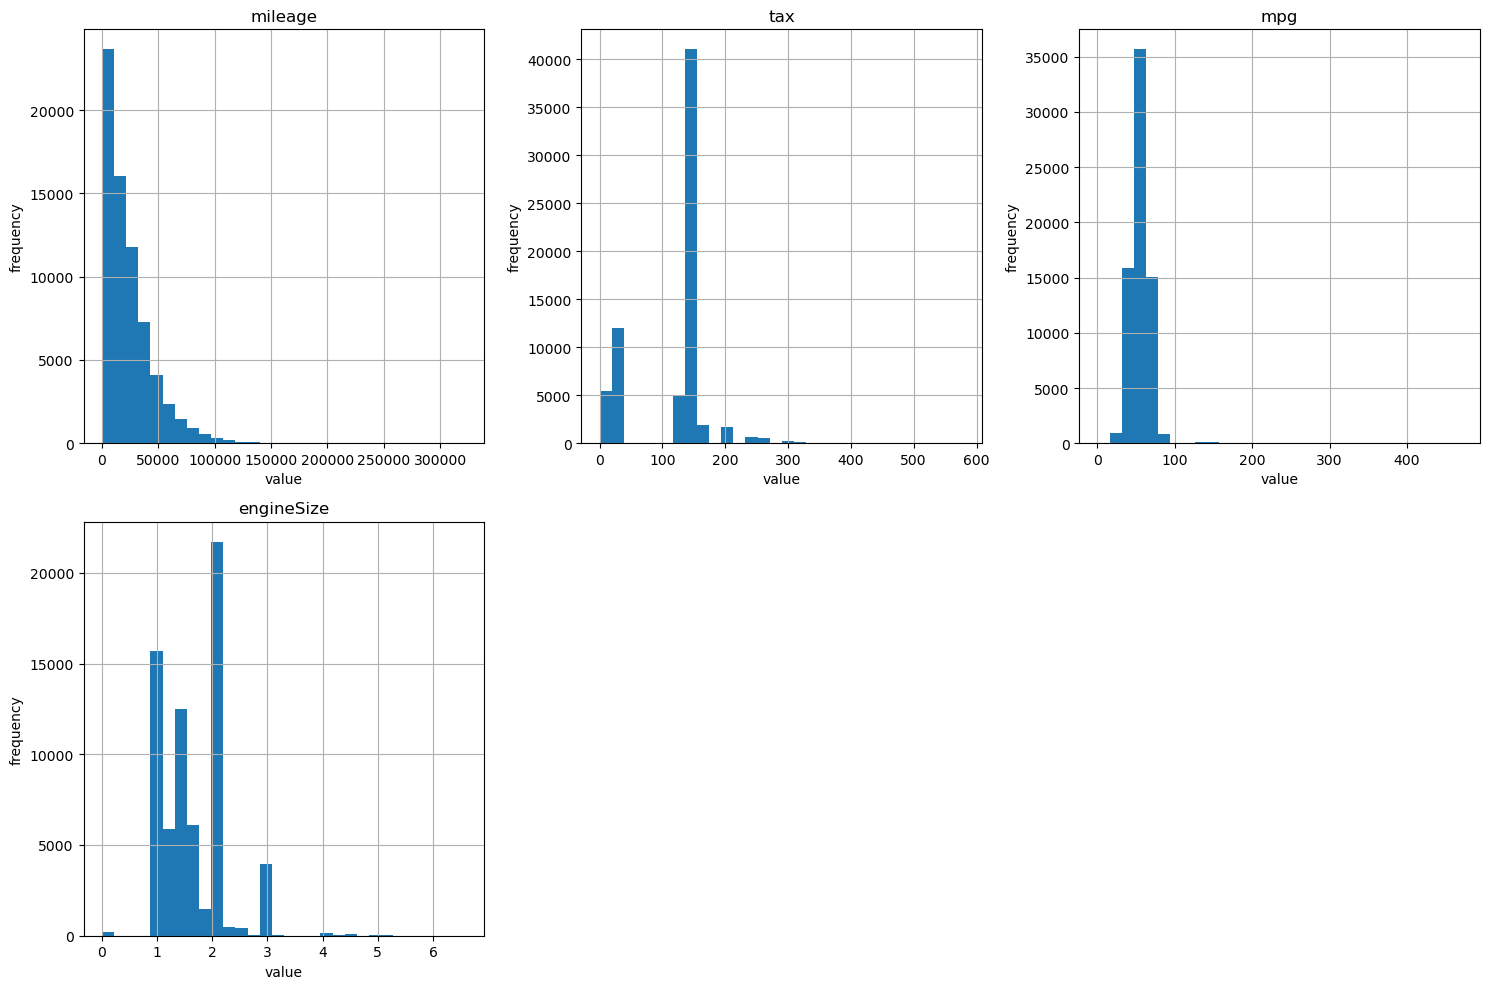

In [10]:
def plot_numeric_distribution(df, num_cols, bins=30):
    
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(15, 5 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        df[col].hist(bins=bins)
        plt.title(col)
        plt.xlabel("value")
        plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()

plot_numeric_distribution(df, NUM_FEATURES)

## Checking for missing data per column

In [ ]:
df.isna().sum()

# I have to drop all null values from price column
# Because it is my target

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

In [22]:
df.dropna(subset=['price'], inplace=True)

## Checking for Rare labels and high cardinality

In [ ]:
def get_label_percentage(df: pd.DataFrame, cat_cols: list) -> pd.DataFrame:
    results = []

    for col in cat_cols:
        value_counts = df[col].value_counts(normalize=True) * 100
        
        temp_df = value_counts.reset_index()
        temp_df.columns = ["label", "percentage"]
        temp_df["column"] = col
        
        results.append(temp_df)

    final_df = pd.concat(results)

    final_df = final_df.set_index("column")

    return final_df

high_cardinality_and_rare_labels = get_label_percentage(df=df, cat_cols=CAT_FEATURES)
high_cardinality_and_rare_labels

# [Other] categery from transmission is a rare categery
# [Hybrid, Other, Electric] from fuelType are also a rare categeroies, I have to compine them in one category

,label,percentage
column,,
transmission,Manual,59.288501
transmission,Semi-Auto,21.256216
transmission,Automatic,19.449162
transmission,Other,0.006120
fuelType,Petrol,55.824522
fuelType,Diesel,39.863510
fuelType,Hybrid,3.986045
fuelType,Other,0.318272
fuelType,Electric,0.007651


# Building model